In [84]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rubenisuparno/dirty-cafe-sales-datasets")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/rubenisuparno/dirty-cafe-sales-datasets


In [85]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [86]:
df = pd.read_csv("/kaggle/input/datasets/rubenisuparno/dirty-cafe-sales-datasets/dirty_dataset/dirty_cafe_sales3.csv")

 # Initial Inspection

In [87]:
df.head()



,Unnamed: 0,Transaction ID,Transaction Date,Menu,Category,Menu ID,Qty,Price,Total Spent,Payment Method,Order Type
0,0,SUN-6791378,2025-06-22,Mineral Water,Drinks,DRK-15,3,12000,36000,Cash,Dine In
1,1,SUN-4902738,2025-07-06,Berry Smoothies,Drinks,missing,3,36000,108000,Digital Wallet,Take Away
2,2,SUN-7750854,NaN,Virgin Mojito,Drinks,DRK-09,4,28000,112000,missing,Dine In
3,3,SUN-2304293,2025-12-13,Fudgy Brownies,Dessert,DST-02,2,25000,50000,missing,missing
4,4,SUN-5669725,2025-01-13,Churros with Chocolate Dip,Dessert,DST-10,4,27000,NaN,Cash,Take Away


In [88]:
print(df.tail())



       Unnamed: 0 Transaction ID Transaction Date             Menu Category  \
99995       99995    SUN-8410736       2025-10-30   Iced Americano   Drinks   
99996       99996    SUN-2165590       2025-04-18    Thai Milk Tea   Drinks   
99997       99997    SUN-8544375       2025-03-16  Choco Lava Cake  Dessert   
99998       99998    SUN-1692759       2025-01-04   Espreso Single   Drinks   
99999       99999    SUN-7293899       2025-11-07   Lychee Tea Ice   Drinks   

      Menu ID      Qty  Price Total Spent  Payment Method Order Type  
99995  DRK-02        3  28000       84000      Debit Card    Dine In  
99996  DRK-08        2  27000       54000      Debit Card    Dine In  
99997  DST-04        2  35000       70000            Cash    Dine In  
99998  DRK-01        2  22000       44000      Debit Card  Take Away  
99999  DRK-07  unknown  25000       50000  Digital Wallet    Dine In  


In [89]:
df.shape



(100000, 11)

In [99]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Unnamed: 0        100000 non-null  int64         
 1   Transaction ID    100000 non-null  object        
 2   Transaction Date  92818 non-null   datetime64[ns]
 3   Menu              88360 non-null   object        
 4   Category          91688 non-null   object        
 5   Menu ID           94757 non-null   object        
 6   Qty               93256 non-null   object        
 7   Price             91418 non-null   object        
 8   Total Spent       89240 non-null   object        
 9   Payment Method    88347 non-null   object        
 10  Order Type        89714 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 8.4+ MB


In [91]:
df.describe(include='all')

,Unnamed: 0,Transaction ID,Transaction Date,Menu,Category,Menu ID,Qty,Price,Total Spent,Payment Method,Order Type
count,100000.000000,100000,98129,97077,97904,98735,98256,97883,97299,97172,97420
unique,NaN,100000,368,38,6,38,7,22,64,6,6
top,NaN,SUN-7172358,error,error,Drinks,FOD-05,2,28000,84000,Debit Card,Online Order
freq,NaN,1,1826,2932,39226,2808,23387,10447,4570,34307,29919
mean,49999.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,28867.657797,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,24999.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,49999.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,74999.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
missing = df.isnull().sum()

missing

Unnamed: 0             0
Transaction ID         0
Transaction Date    1871
Menu                2923
Category            2096
Menu ID             1265
Qty                 1744
Price               2117
Total Spent         2701
Payment Method      2828
Order Type          2580
dtype: int64

In [44]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent

Unnamed: 0          0.000
Transaction ID      0.000
Transaction Date    1.871
Menu                2.923
Category            2.096
Menu ID             1.265
Qty                 1.744
Price               2.117
Total Spent         2.701
Payment Method      2.828
Order Type          2.580
dtype: float64

In [45]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [46]:
df.dtypes

Unnamed: 0           int64
Transaction ID      object
Transaction Date    object
Menu                object
Category            object
Menu ID             object
Qty                 object
Price               object
Total Spent         object
Payment Method      object
Order Type          object
dtype: object

In [47]:
df.describe()

,Unnamed: 0
count,100000.000000
mean,49999.500000
std,28867.657797
min,0.000000
25%,24999.750000
50%,49999.500000
75%,74999.250000
max,99999.000000


In [92]:
missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().sum()/len(df)*100
).round(2)

before_missing = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

before_missing

,Missing Count,Missing Percentage
Unnamed: 0,0,0.00
Transaction ID,0,0.00
Transaction Date,1871,1.87
Menu,2923,2.92
Category,2096,2.10
Menu ID,1265,1.26
Qty,1744,1.74
Price,2117,2.12
Total Spent,2701,2.70
Payment Method,2828,2.83


In [93]:
duplicate_before = df.duplicated().sum()

print("Duplicate Rows:", duplicate_before)

Duplicate Rows: 0


In [94]:
for col in df.select_dtypes(include="object"):
    print("="*50)
    print(col)
    print(df[col].unique())

Transaction ID
['SUN-6791378' 'SUN-4902738' 'SUN-7750854' ... 'SUN-8544375' 'SUN-1692759'
 'SUN-7293899']
Transaction Date
['2025-06-22' '2025-07-06' nan '2025-12-13' '2025-01-13' 'unknown'
 '2025-10-28' '2025-04-01' '2025-04-24' '2025-11-14' '2025-06-04'
 '2025-04-10' '2025-10-30' '2025-04-04' '2025-05-30' 'error' '2025-07-20'
 '2025-02-01' '2025-01-11' '2025-11-12' '2025-11-02' '2025-07-16'
 '2025-10-26' '2025-06-15' '2025-10-15' '2025-02-15' '2025-04-21'
 '2025-12-23' '2025-02-18' 'missing' '2025-11-26' '2025-03-16'
 '2025-07-03' '2025-04-06' '2025-01-08' '2025-10-01' '2025-01-23'
 '2025-04-13' '2025-07-01' '2025-06-27' '2025-02-12' '2025-12-24'
 '2025-12-18' '2025-02-03' '2025-09-22' '2025-04-17' '2025-07-17'
 '2025-12-04' '2025-04-12' '2025-02-28' '2025-04-28' '2025-12-21'
 '2025-06-03' '2025-07-08' '2025-08-16' '2025-06-16' '2025-10-11'
 '2025-05-13' '2025-08-12' '2025-10-10' '2025-12-01' '2025-06-05'
 '2025-01-15' '2025-09-20' '2025-11-15' '2025-06-17' '2025-05-15'
 '2025-08-23'

In [95]:
invalid_values = ["error", "unknown", "missing"]

for value in invalid_values:
    print(f"\nOccurrences of '{value}':")
    print((df == value).sum())


Occurrences of 'error':
Unnamed: 0             0
Transaction ID         0
Transaction Date    1826
Menu                2932
Category            2086
Menu ID             1322
Qty                 1636
Price               2153
Total Spent         2636
Payment Method      2865
Order Type          2654
dtype: int64

Occurrences of 'unknown':
Unnamed: 0             0
Transaction ID         0
Transaction Date    1796
Menu                2870
Category            2066
Menu ID             1313
Qty                 1684
Price               2113
Total Spent         2706
Payment Method      2987
Order Type          2537
dtype: int64

Occurrences of 'missing':
Unnamed: 0             0
Transaction ID         0
Transaction Date    1689
Menu                2915
Category            2064
Menu ID             1343
Qty                 1680
Price               2199
Total Spent         2717
Payment Method      2973
Order Type          2515
dtype: int64


In [96]:
invalid_values = ["error", "unknown", "missing"]

df.replace(invalid_values, np.nan, inplace=True)

In [97]:
df.isnull().sum()

Unnamed: 0              0
Transaction ID          0
Transaction Date     7182
Menu                11640
Category             8312
Menu ID              5243
Qty                  6744
Price                8582
Total Spent         10760
Payment Method      11653
Order Type          10286
dtype: int64

In [100]:
df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce"
)
df["Qty"] = pd.to_numeric(
    df["Qty"],
    errors="coerce"
)

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)
df["Total Spent"] = pd.to_numeric(
    df["Total Spent"],
    errors="coerce"
)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Unnamed: 0        100000 non-null  int64         
 1   Transaction ID    100000 non-null  object        
 2   Transaction Date  92818 non-null   datetime64[ns]
 3   Menu              88360 non-null   object        
 4   Category          91688 non-null   object        
 5   Menu ID           94757 non-null   object        
 6   Qty               93256 non-null   float64       
 7   Price             91418 non-null   float64       
 8   Total Spent       89240 non-null   float64       
 9   Payment Method    88347 non-null   object        
 10  Order Type        89714 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 8.4+ MB


# # : Missing Value Handling

In [102]:
print("========== Missing Values (Before Cleaning) ==========\n")
print(df.isnull().sum())

========== Missing Values (Before Cleaning) ==========

Unnamed: 0              0
Transaction ID          0
Transaction Date     7182
Menu                11640
Category             8312
Menu ID              5243
Qty                  6744
Price                8582
Total Spent         10760
Payment Method      11653
Order Type          10286
dtype: int64


In [103]:
before_missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": ((df.isnull().sum() / len(df)) * 100).round(2)
})

before_missing

,Missing Count,Missing Percentage
Unnamed: 0,0,0.00
Transaction ID,0,0.00
Transaction Date,7182,7.18
Menu,11640,11.64
Category,8312,8.31
Menu ID,5243,5.24
Qty,6744,6.74
Price,8582,8.58
Total Spent,10760,10.76
Payment Method,11653,11.65


In [104]:
# Transaction Date
df["Transaction Date"] = df["Transaction Date"].ffill()

# Menu
df["Menu"] = df["Menu"].fillna(df["Menu"].mode()[0])

# Category
df["Category"] = df["Category"].fillna(df["Category"].mode()[0])

# Qty
df["Qty"] = pd.to_numeric(df["Qty"], errors="coerce")
df["Qty"] = df["Qty"].fillna(df["Qty"].median())

# Price
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Price"] = df["Price"].fillna(df["Price"].median())

# Total Spent
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")
df["Total Spent"] = df["Qty"] * df["Price"]

# Payment Method
df["Payment Method"] = df["Payment Method"].fillna(df["Payment Method"].mode()[0])

# Order Type
df["Order Type"] = df["Order Type"].fillna(df["Order Type"].mode()[0])

# Menu ID (recommended mapping approach)
menu_mapping = (
    df.dropna(subset=["Menu", "Menu ID"])
      .drop_duplicates(subset=["Menu"])
      .set_index("Menu")["Menu ID"]
)

df["Menu ID"] = df["Menu ID"].fillna(df["Menu"].map(menu_mapping))

In [105]:
print("========== Missing Values (After Cleaning) ==========\n")
print(df.isnull().sum())

========== Missing Values (After Cleaning) ==========

Unnamed: 0          0
Transaction ID      0
Transaction Date    0
Menu                0
Category            0
Menu ID             0
Qty                 0
Price               0
Total Spent         0
Payment Method      0
Order Type          0
dtype: int64


In [106]:
print("========== Missing Value Percentage (After Cleaning) ==========\n")

missing_percentage_after = (df.isnull().sum() / len(df)) * 100

print(missing_percentage_after.round(2))

========== Missing Value Percentage (After Cleaning) ==========

Unnamed: 0          0.0
Transaction ID      0.0
Transaction Date    0.0
Menu                0.0
Category            0.0
Menu ID             0.0
Qty                 0.0
Price               0.0
Total Spent         0.0
Payment Method      0.0
Order Type          0.0
dtype: float64


In [107]:
after_missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": ((df.isnull().sum() / len(df)) * 100).round(2)
})

after_missing

,Missing Count,Missing Percentage
Unnamed: 0,0,0.0
Transaction ID,0,0.0
Transaction Date,0,0.0
Menu,0,0.0
Category,0,0.0
Menu ID,0,0.0
Qty,0,0.0
Price,0,0.0
Total Spent,0,0.0
Payment Method,0,0.0


In [108]:
comparison = pd.DataFrame({
    "Before Count": before_missing["Missing Count"],
    "After Count": after_missing["Missing Count"],
    "Before %": before_missing["Missing Percentage"],
    "After %": after_missing["Missing Percentage"]
})

comparison

,Before Count,After Count,Before %,After %
Unnamed: 0,0,0,0.00,0.0
Transaction ID,0,0,0.00,0.0
Transaction Date,7182,0,7.18,0.0
Menu,11640,0,11.64,0.0
Category,8312,0,8.31,0.0
Menu ID,5243,0,5.24,0.0
Qty,6744,0,6.74,0.0
Price,8582,0,8.58,0.0
Total Spent,10760,0,10.76,0.0
Payment Method,11653,0,11.65,0.0


In [109]:
duplicate_before = df.duplicated().sum()

print("Duplicate Rows Before Cleaning:", duplicate_before)

Duplicate Rows Before Cleaning: 0


In [110]:
df = df.drop_duplicates()

In [111]:
duplicate_after = df.duplicated().sum()

print("Duplicate Rows After Cleaning:", duplicate_after)

Duplicate Rows After Cleaning: 0


In [112]:
duplicate_comparison = pd.DataFrame({
    "Metric": ["Duplicate Rows"],
    "Before": [duplicate_before],
    "After": [duplicate_after],
    "Removed": [duplicate_before - duplicate_after]
})

duplicate_comparison

,Metric,Before,After,Removed
0,Duplicate Rows,0,0,0


# standerize 

In [113]:
text_cols = [
    "Menu",
    "Category",
    "Payment Method",
    "Order Type"
]

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

In [114]:
df["Order Type"] = (
    df["Order Type"]
    .str.strip()
    .str.title()
)

In [115]:
df["Menu"] = df["Menu"].str.strip()

In [60]:
df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce"
)

In [61]:
df["Transaction ID"] = df["Transaction ID"].astype(str)

df["Menu ID"] = df["Menu ID"].astype(str)

# outliera detection

In [116]:
numeric_cols = ["Qty", "Price", "Total Spent"]

outlier_before = {}

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_before[col] = (
        ((df[col] < lower) | (df[col] > upper)).sum()
    )

pd.DataFrame.from_dict(
    outlier_before,
    orient="index",
    columns=["Outliers Before"]
)

,Outliers Before
Qty,0
Price,0
Total Spent,600


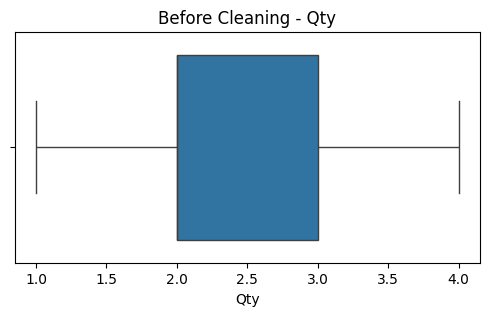

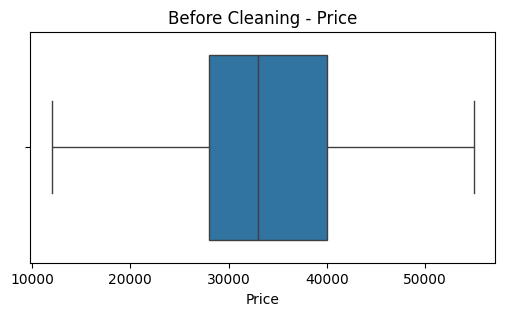

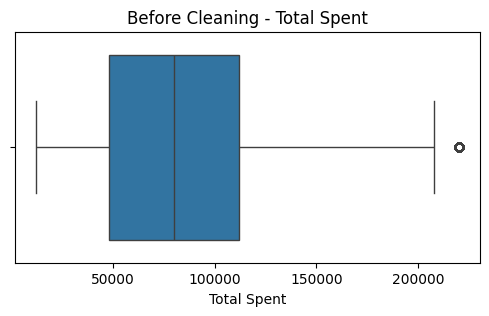

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Before Cleaning - {col}")
    plt.show()

In [118]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower, upper=upper)

In [119]:
outlier_after = {}

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_after[col] = (
        ((df[col] < lower) | (df[col] > upper)).sum()
    )

pd.DataFrame({
    "Before": outlier_before,
    "After": outlier_after
})

,Before,After
Qty,0,0
Price,0,0
Total Spent,600,0


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Unnamed: 0        100000 non-null  int64         
 1   Transaction ID    100000 non-null  object        
 2   Transaction Date  100000 non-null  datetime64[ns]
 3   Menu              100000 non-null  object        
 4   Category          100000 non-null  object        
 5   Menu ID           100000 non-null  object        
 6   Qty               100000 non-null  float64       
 7   Price             100000 non-null  float64       
 8   Total Spent       100000 non-null  float64       
 9   Payment Method    100000 non-null  object        
 10  Order Type        100000 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 8.4+ MB


In [121]:
df.isnull().sum()

Unnamed: 0          0
Transaction ID      0
Transaction Date    0
Menu                0
Category            0
Menu ID             0
Qty                 0
Price               0
Total Spent         0
Payment Method      0
Order Type          0
dtype: int64

In [122]:
df.describe()

,Unnamed: 0,Transaction Date,Qty,Price,Total Spent
count,100000.000000,100000,100000.000000,100000.000000,100000.000000
mean,49999.500000,2025-07-01 12:07:55.200000,2.464480,34361.400000,84620.040000
min,0.000000,2025-01-01 00:00:00,1.000000,12000.000000,12000.000000
25%,24999.750000,2025-04-01 00:00:00,2.000000,28000.000000,48000.000000
50%,49999.500000,2025-07-01 00:00:00,2.000000,33000.000000,80000.000000
75%,74999.250000,2025-10-01 00:00:00,3.000000,40000.000000,112000.000000
max,99999.000000,2025-12-31 00:00:00,4.000000,55000.000000,208000.000000
std,28867.657797,NaN,1.086918,9050.968414,44429.238458


In [123]:
df.to_csv("Restaurant_Data_Cleaned.csv", index=False)